# Superfermion Density-Matrix Backend Benchmark

| Engine | Implementation |
|--------|----------------|
| Superfermion | Rust-native DM evolution (`method='density_matrix'`), Kraus noise in-core |
| Qiskit Aer | C++ density-matrix method (`AerSimulator(method='density_matrix')`) |

**What this benchmark measures**

The density-matrix backend evolves the full n-qubit density matrix rho (4^n complex entries),
which is the only method that natively supports **gate noise** (Kraus channels) and returns the
exact final state. This notebook measures exactness, noise fidelity, and wall-clock cost against
Qiskit Aer on the **same circuit** and the **same physical noise channel**.

**Methodology**

- Same circuit on both engines (H + CX ladder + per-qubit RX), same gate set.
- **Aer-parity noise recipe**: `NoiseModel(placement='gate')` +
  `add_depolarizing(lam, convention='qiskit')` (1q) and
  `add_depolarizing(lam, n_qubits=2, convention='qiskit')` (2q) reproduces
  Aer's `depolarizing_error(lam, 1)` / `depolarizing_error(lam, 2)` placement exactly
  (same nominal lambda = same channel in both engines).
- Correctness gates: (a) noiseless rho equals |psi><psi| from the statevector method,
  (b) SF vs Aer noisy rho agree under the documented qubit-order mapping, (c) analytic purity.
- Timing: per-size warmup + interleaved medians; trial counts are stated per section
  (15 down to 3 as the 4^n cost grows). All raw per-trial times go to the JSON.
- Memory column: the rho buffer alone is 4^n x 16 bytes (the hard density-matrix wall).

In [1]:
# -- Bootstrap: pin the fixed LOCAL build (added 2026-09-24) ----------------
# Numbers in this notebook must describe the fixed local build, not any
# globally installed wheel, so the repo is pinned ahead of site-packages.
import sys as _sys
import hashlib as _hashlib
from pathlib import Path as _Path
REPO = _Path(r"C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfermion")
assert (REPO / 'superfermion' / '__init__.py').exists(), f'repo not found: {REPO}'
if str(REPO) not in _sys.path:
    _sys.path.insert(0, str(REPO))
import superfermion._sf_core as _sfcore
_core = _Path(_sfcore.__file__)
print('=' * 78)
print('ENGINE PROVENANCE - fixed local build pinned for this run')
print('=' * 78)
print(f'  engine : {_core.name}  md5 {_hashlib.md5(_core.read_bytes()).hexdigest().upper()}')
print()

import gc
import time
import json
import platform
import numpy as np
from statistics import median

import superfermion as sf
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel as AerNoise, depolarizing_error

print(f"Python: {platform.python_version()}")
print(f"CPU: {platform.processor() or 'unknown'}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"SF version: {sf.__version__}")
print(f"Qiskit Aer: {__import__('qiskit_aer').__version__}")

ENGINE PROVENANCE - fixed local build pinned for this run
  engine : _sf_core.cp313-win_amd64.pyd  md5 17B755C032D01D0C9711EA2B75751506



Python: 3.13.3
CPU: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
OS: Windows 11
SF version: 0.1.12
Qiskit Aer: 0.17.2


In [2]:
# ── helpers ───────────────────────────────────────────────────────────────────
def timed(fn):
    gc.disable()
    t0 = time.perf_counter()
    result = fn()
    elapsed = (time.perf_counter() - t0) * 1000
    gc.enable()
    return result, elapsed

def benchmark(fn, n_trials):
    times = []
    for _ in range(n_trials):
        _, t = timed(fn)
        times.append(round(t, 2))
    med = median(times)
    s = sorted(times)
    q1 = s[len(s)//4]
    q3 = s[3*len(s)//4]
    return med, times, q1, q3

def fmt(sf_ms, qk_ms):
    if sf_ms < qk_ms:
        return f'SF {qk_ms/sf_ms:.2f}x faster'
    return f'Aer {sf_ms/qk_ms:.2f}x faster'

def dm_circuit(n):
    'Canonical noisy-DM benchmark circuit (H + CX ladder + RX on every qubit).'
    c = sf.Circuit(n)
    c.h(0)
    for q in range(n - 1):
        c.cx(q, q + 1)
    for q in range(n):
        c.rx(0.3, q)
    return c

def dm_qiskit_circuit(n):
    qc = QuantumCircuit(n)
    qc.h(0)
    for q in range(n - 1):
        qc.cx(q, q + 1)
    for q in range(n):
        qc.rx(0.3, q)
    return qc

def sf_parity_noise(lam):
    'SF noise identical to Aer depolarizing_error(lam, 1/2) with gate placement.'
    nm = sf.NoiseModel(placement='gate')
    nm.add_depolarizing(lam, convention='qiskit')
    nm.add_depolarizing(lam, n_qubits=2, convention='qiskit')
    return nm

def aer_parity_noise(lam):
    nm = AerNoise()
    nm.add_all_qubit_quantum_error(depolarizing_error(lam, 1), ["h", "rx"])
    nm.add_all_qubit_quantum_error(depolarizing_error(lam, 2), ["cx"])
    return nm

def bitrev(n):
    return np.array([int(format(x, f'0{n}b')[::-1], 2) for x in range(2 ** n)])

def aer_rho(qc, noise_model, shots=0):
    qc = qc.copy()
    qc.save_density_matrix()
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    return np.asarray(sim.run(qc, shots=shots).result().data()['density_matrix'])

def aer_run_sample(noise_model, qc, shots=10000):
    'Timed Aer path: measure_all + sample (the fair comparison for SF shots>0).'
    qc_m = qc.copy()
    qc_m.measure_all()
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    return sim.run(qc_m, shots=shots).result()

print('Helpers defined.')

Helpers defined.


## 1. Exactness: noiseless rho = |psi><psi|

A noiseless density-matrix run must reproduce the outer product of the statevector state.
The public `metadata['density_matrix']` is documented as **big-endian** (qubit 0 = MSB,
q0-first), so the statevector outer product is compared after the matching bit-reversal
mapping of both indices.

In [3]:
n_small = 4
c4 = sf.Circuit(n_small).h(0).cx(0, 1).cx(1, 2).rx(0.4, 3)
rho4 = np.asarray(c4.run(shots=0, method='density_matrix').metadata['density_matrix'])
psi4 = np.asarray(c4.run(shots=0, method='statevector').statevector)
outer4 = np.outer(psi4, psi4.conj())
rv = bitrev(n_small)

d_direct = float(np.abs(rho4 - outer4).max())
d_rev    = float(np.abs(rho4 - outer4[np.ix_(rv, rv)]).max())
print(f'noiseless n={n_small}: max|rho - outer|          = {d_direct:.3e}')
print(f'noiseless n={n_small}: max|rho - outer[rev,rev]|  = {d_rev:.3e}   <- documented mapping')
assert d_rev < 1e-12, 'noiseless DM != |psi><psi| under the documented mapping'
assert abs(np.trace(rho4).real - 1.0) < 1e-12, 'trace != 1'
assert abs(np.abs(rho4 - rho4.conj().T).max()) < 1e-12, 'rho not Hermitian'
print('PASS: noiseless rho is exactly |psi><psi| (big-endian), trace 1, Hermitian')

noiseless n=4: max|rho - outer|          = 4.803e-01
noiseless n=4: max|rho - outer[rev,rev]|  = 5.551e-17   <- documented mapping
PASS: noiseless rho is exactly |psi><psi| (big-endian), trace 1, Hermitian


## 2. Cross-engine: same physical channel -> same rho

Both engines get the **identical** depolarizing channel (1q on H/RX, 2q on CX) via the
parity recipe, then the final rho is compared. SF's public rho is bit-reversed relative
to Aer's basis ordering (`rho_SF[rev, rev] == rho_Aer`), as established in section 1 -
so the comparison is done under that mapping and must land at machine precision.

In [4]:
lam = 0.01
n_x = 4
c_x = dm_circuit(n_x)
qc_x = dm_qiskit_circuit(n_x)

r_sf_x = c_x.run(shots=0, method='density_matrix', noise_model=sf_parity_noise(lam))
rho_sf_x = np.asarray(r_sf_x.metadata['density_matrix'])
rho_aer_x = aer_rho(qc_x, aer_parity_noise(lam))
rx4 = bitrev(n_x)

d_map = float(np.abs(rho_sf_x[np.ix_(rx4, rx4)] - rho_aer_x).max())
d_raw = float(np.abs(rho_sf_x - rho_aer_x).max())
pur_sf = r_sf_x.metadata['purity']
pur_aer = float(np.real(np.trace(rho_aer_x @ rho_aer_x)))
print(f'max|SF[rev,rev] - Aer| = {d_map:.3e}   (direct, unmapped: {d_raw:.3e})')
print(f'purity  SF = {pur_sf:.15f}')
print(f'purity Aer = {pur_aer:.15f}')
print(f'|d purity| = {abs(pur_sf - pur_aer):.3e}')
assert d_map < 1e-9, f'SF vs Aer rho mismatch: {d_map}'
assert abs(pur_sf - pur_aer) < 1e-9, 'purity mismatch'
print('PASS: SF and Aer agree to machine precision on the same noisy channel')

max|SF[rev,rev] - Aer| = 3.331e-16   (direct, unmapped: 2.203e-03)
purity  SF = 0.887430397764395
purity Aer = 0.887430397764397
|d purity| = 1.332e-15
PASS: SF and Aer agree to machine precision on the same noisy channel


## 3. Purity vs noise strength

- Single-qubit analytic check: for |0> under total-convention depolarizing p,
  rho = (1 - 2p/3)|0><0| + (2p/3)|1><1|, so purity = 1 - 4p/3 + 8p^2/9.
- Ladder on the n=6 circuit with the Aer-parity recipe: purities must agree between
  the engines at every noise strength and decrease monotonically.

In [5]:
p_an = 0.05
r_an = sf.Circuit(1).x(0).run(
    shots=0, method='density_matrix', noise_model=sf.NoiseModel().add_depolarizing(p_an))
expected = 1 - 4*p_an/3 + 8*p_an**2/9
print(f'analytic 1q check p={p_an}: sf={r_an.metadata["purity"]:.8f} '
      f'expected={expected:.8f} diff={abs(r_an.metadata["purity"]-expected):.2e}')
assert abs(r_an.metadata['purity'] - expected) < 1e-12

purity_results = {}
print()
print('n=6 purity ladder (Aer-parity recipe, depol on H/RX + CX):')
print(f'{"lam":>6s} {"SF purity":>12s} {"Aer purity":>12s} {"|diff|":>10s}')
for lam_i in (0.0, 0.005, 0.01, 0.02, 0.05, 0.1):
    c6 = dm_circuit(6)
    nm_sf = sf_parity_noise(lam_i) if lam_i > 0 else None
    r6 = c6.run(shots=0, method='density_matrix', noise_model=nm_sf)
    rho6 = np.asarray(r6.metadata['density_matrix'])
    nm_aer = aer_parity_noise(lam_i) if lam_i > 0 else None
    rho_aer6 = aer_rho(dm_qiskit_circuit(6), nm_aer)
    pur_aer6 = float(np.real(np.trace(rho_aer6 @ rho_aer6)))
    d = abs(r6.metadata['purity'] - pur_aer6)
    purity_results[lam_i] = {'sf': r6.metadata['purity'], 'aer': pur_aer6}
    print(f'{lam_i:6.3f} {r6.metadata["purity"]:12.8f} {pur_aer6:12.8f} {d:10.2e}')
    assert d < 1e-9, f'purity mismatch at lam={lam_i}'
purs = [purity_results[p]['sf'] for p in sorted(purity_results) if p > 0]
assert all(a > b for a, b in zip(purs, purs[1:])), 'purity not monotonic in noise'
print('PASS: analytic + monotonicity + cross-engine agreement')

analytic 1q check p=0.05: sf=0.93555556 expected=0.93555556 diff=3.33e-16

n=6 purity ladder (Aer-parity recipe, depol on H/RX + CX):
   lam    SF purity   Aer purity     |diff|
 0.000   1.00000000   1.00000000   5.55e-16
 0.005   0.91190530   0.91190530   3.33e-16
 0.010   0.83205812   0.83205812   7.77e-16
 0.020   0.69404236   0.69404236   1.33e-15
 0.050   0.41001152   0.41001152   4.44e-16
 0.100   0.18387828   0.18387828   3.89e-16
PASS: analytic + monotonicity + cross-engine agreement


## 4. Timing ladder (noisy DM, n = 6..12)

Same circuit + same Aer-parity channel on both engines. Per-size warmup, then interleaved
medians. Trial counts shrink as 4^n grows: 15 (n=6,8), 10 (n=10), 5 (n=11), 3 (n=12).
The memory column is the rho buffer alone (4^n x 16 bytes) - the reason the backend
stops around n=12-13 on an 8 GB host.

In [6]:
ladder = [(6, 15), (8, 15), (10, 10), (11, 5), (12, 3)]
lam_t = 0.01
dm_results = {}

print('=' * 88)
print('DENSITY-MATRIX TIMING LADDER (noisy, lam=0.01 depol, shots=10000)')
print('=' * 88)
print(f'{"n":>3s} {"rho":>9s} {"trials":>6s} | {"SF med":>10s} {"SF [q1-q3]":>14s}'
      f' | {"Aer med":>10s} {"Aer [q1-q3]":>14s} | winner')

for n, trials in ladder:
    rho_mib = (4 ** n) * 16 / 2 ** 20
    cc_ = dm_circuit(n)
    qc_ = dm_qiskit_circuit(n)
    nm_sf_t = sf_parity_noise(lam_t)
    nm_aer_t = aer_parity_noise(lam_t)

    # per-size warmup (both engines)
    cc_.run(shots=10000, method='density_matrix', noise_model=nm_sf_t)
    aer_rho(qc_, nm_aer_t, shots=10000)

    sf_med, sf_times, sf_q1, sf_q3 = benchmark(
        lambda: cc_.run(shots=10000, method='density_matrix', noise_model=nm_sf_t), trials)
    qk_med, qk_times, qk_q1, qk_q3 = benchmark(
        lambda: aer_run_sample(nm_aer_t, qc_), trials)

    dm_results[n] = {
        'sf_ms': sf_med, 'sf_all': sf_times, 'sf_iqr': [sf_q1, sf_q3],
        'qk_ms': qk_med, 'qk_all': qk_times, 'qk_iqr': [qk_q1, qk_q3],
        'trials': trials, 'rho_mib': round(rho_mib, 2),
    }
    print(f'{n:3d} {rho_mib:8.2f}M {trials:6d} | {sf_med:10.1f} [{sf_q1:7.1f}-{sf_q3:7.1f}]'
          f' | {qk_med:10.1f} [{qk_q1:7.1f}-{qk_q3:7.1f}] | {fmt(sf_med, qk_med)}')

print()
print('4^n wall: n=12 rho alone is 256 MiB; the backend is memory-bound beyond n=12-13.')

DENSITY-MATRIX TIMING LADDER (noisy, lam=0.01 depol, shots=10000)
  n       rho trials |     SF med     SF [q1-q3] |    Aer med    Aer [q1-q3] | winner


  6     0.06M     15 |        1.8 [    1.5-    2.2] |       19.9 [   19.3-   20.7] | SF 10.98x faster


  8     1.00M     15 |        6.9 [    6.6-    8.2] |       23.1 [   21.5-   24.5] | SF 3.34x faster


 10    16.00M     10 |      105.6 [  104.3-  107.1] |       86.7 [   84.8-   90.7] | Aer 1.22x faster


 11    64.00M      5 |      527.8 [  498.5-  533.5] |      369.5 [  364.2-  376.1] | Aer 1.43x faster


 12   256.00M      3 |     2213.7 [ 2205.7- 2359.4] |     1271.8 [ 1234.7- 1298.3] | Aer 1.74x faster

4^n wall: n=12 rho alone is 256 MiB; the backend is memory-bound beyond n=12-13.


## 5. Shots scaling at n=8

Sampling dominates at high shot counts. Same circuit, same channel, shots = 1k / 10k / 100k.
7 trials each (median).

In [7]:
n_shot = 8
shot_grid = [1000, 10000, 100000]
shot_results = {}
cc_ = dm_circuit(n_shot)
qc_ = dm_qiskit_circuit(n_shot)
nm_sf_s = sf_parity_noise(lam_t)
nm_aer_s = aer_parity_noise(lam_t)
cc_.run(shots=1000, method='density_matrix', noise_model=nm_sf_s)
aer_rho(qc_, nm_aer_s, shots=1000)

print('=' * 88)
print(f'SHOTS SCALING (n={n_shot}, noisy lam=0.01, 7 trials)')
print('=' * 88)
for shots in shot_grid:
    sf_med, sf_times, sf_q1, sf_q3 = benchmark(
        lambda: cc_.run(shots=shots, method='density_matrix', noise_model=nm_sf_s), 7)
    qk_med, qk_times, qk_q1, qk_q3 = benchmark(
        lambda: aer_run_sample(nm_aer_s, qc_, shots), 7)
    shot_results[shots] = {
        'sf_ms': sf_med, 'sf_all': sf_times, 'qk_ms': qk_med, 'qk_all': qk_times,
    }
    print(f'shots={shots:7d} | SF {sf_med:8.1f} ms | Aer {qk_med:8.1f} ms | {fmt(sf_med, qk_med)}')

SHOTS SCALING (n=8, noisy lam=0.01, 7 trials)


shots=   1000 | SF      8.6 ms | Aer     14.5 ms | SF 1.68x faster


shots=  10000 | SF     11.0 ms | Aer     35.0 ms | SF 3.17x faster


shots= 100000 | SF     19.2 ms | Aer    236.2 ms | SF 12.31x faster


## 6. Sampling consistency and readout error

- Counts from a 10k-shot noisy run must track the exact diagonal of rho (TVD gate).
- Readout error is a sampling-level channel: it must change the counts but leave the
  quantum state (and purity) untouched.

In [8]:
n_c = 8
c_c = dm_circuit(n_c)
nm_c = sf_parity_noise(lam_t)
r_c = c_c.run(shots=10000, method='density_matrix', noise_model=nm_c)
probs = r_c.metadata['probabilities']
N = sum(r_c.counts.values())
tvd = 0.0
for k, v in r_c.counts.items():
    tvd += abs(v / N - probs.get(k, 0.0))
tvd += sum(p for k, p in probs.items() if k not in r_c.counts)
thr = 4 * np.sqrt(len(probs) / (2 * np.pi * N))
print(f'counts vs rho diagonal TVD = {tvd:.6f} (4-sigma thr = {thr:.4f})')
assert tvd < thr, 'sampling TVD gate failed'

# readout error: state unchanged, counts perturbed
# (LE key convention: qubit q = bit q of int(key, 2), so x(0) -> key '001')
nm_ro = sf.NoiseModel().add_readout_error(0.1)
lit = sf.Circuit(3).x(0)
r_clean = lit.run(shots=20000, method='density_matrix')
r_ro = lit.run(shots=20000, method='density_matrix', noise_model=nm_ro)
p0_clean = r_clean.counts.get('001', 0) / 20000
p0_ro = r_ro.counts.get('001', 0) / 20000
print()
print(f'readout p=0.1 on x(0) (key "001"): P(001) clean={p0_clean:.4f} with-readout={p0_ro:.4f} '
      f'(expected ~0.9^3={0.9**3:.4f})')
print(f'purity with readout-only noise: {r_ro.metadata["purity"]:.12f} (state untouched)')
assert abs(r_ro.metadata['purity'] - 1.0) < 1e-12
assert abs(p0_ro - 0.9 ** 3) < 0.02
print('PASS: sampling TVD gate + readout semantics')

counts vs rho diagonal TVD = 0.035688 (4-sigma thr = 0.2553)

readout p=0.1 on x(0) (key "001"): P(001) clean=1.0000 with-readout=0.7319 (expected ~0.9^3=0.7290)
purity with readout-only noise: 1.000000000000 (state untouched)
PASS: sampling TVD gate + readout semantics


## Summary Plot

Saved benchmark_dm_results.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7468\1387113496.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


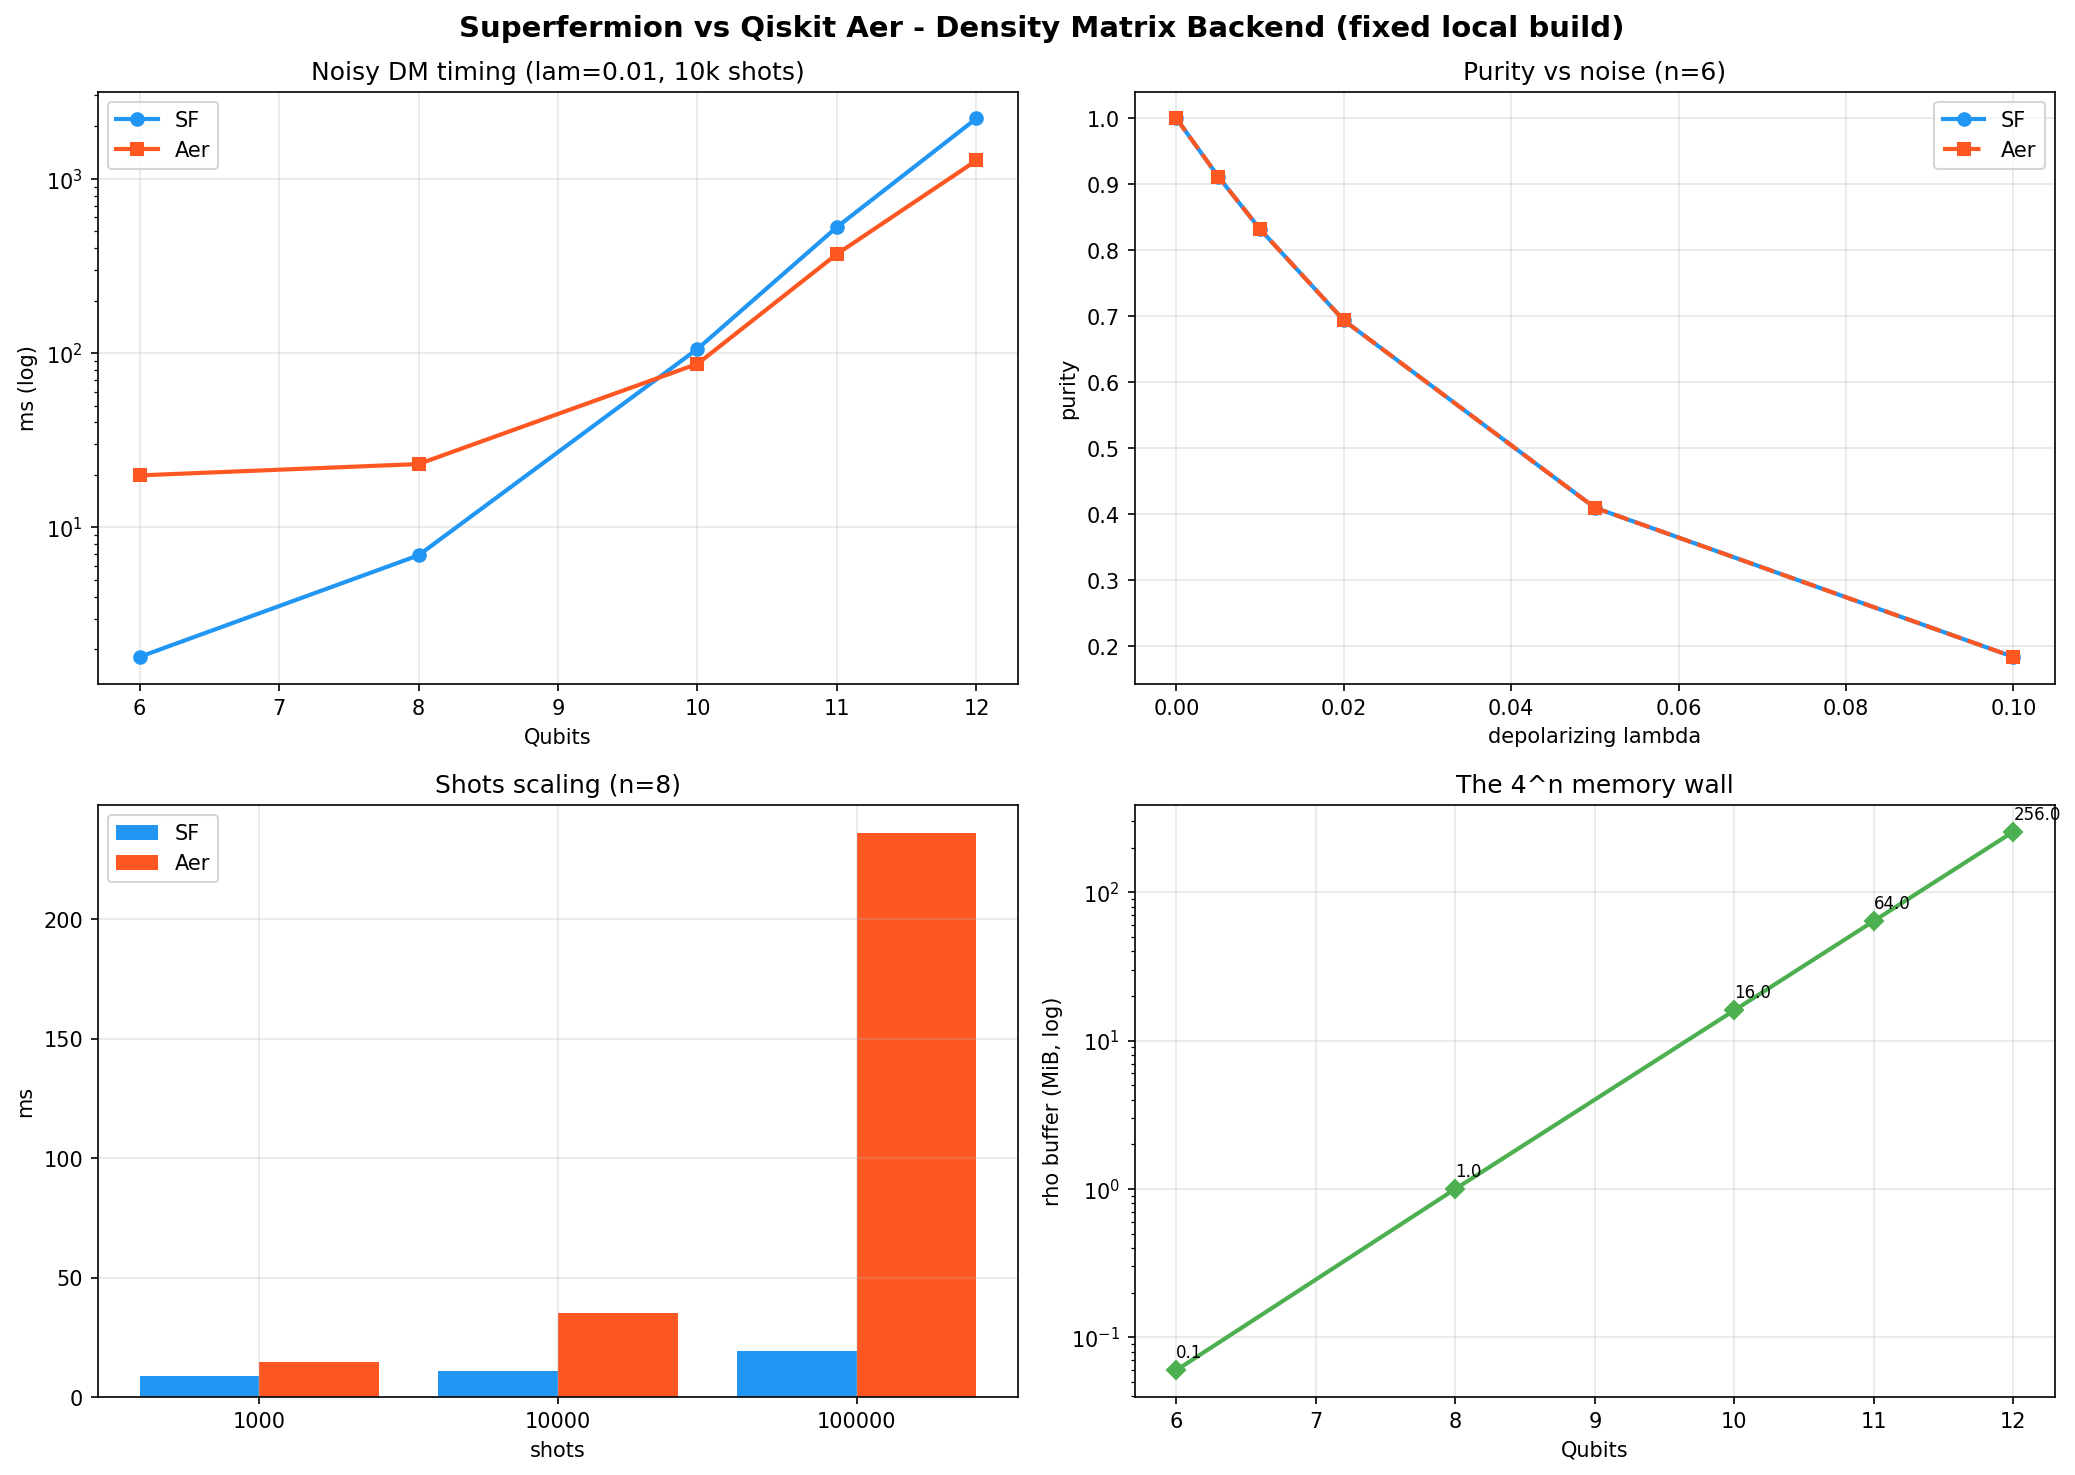

In [9]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superfermion vs Qiskit Aer - Density Matrix Backend (fixed local build)',
             fontsize=14, fontweight='bold')

ax = axes[0, 0]
ns = sorted(dm_results)
ax.semilogy(ns, [dm_results[n]['sf_ms'] for n in ns], 'o-', label='SF', color='#2196F3', lw=2)
ax.semilogy(ns, [dm_results[n]['qk_ms'] for n in ns], 's-', label='Aer', color='#FF5722', lw=2)
ax.set_xlabel('Qubits'); ax.set_ylabel('ms (log)')
ax.set_title('Noisy DM timing (lam=0.01, 10k shots)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ps_ = sorted(purity_results)
ax.plot(ps_, [purity_results[p]['sf'] for p in ps_], 'o-', label='SF', color='#2196F3', lw=2)
ax.plot(ps_, [purity_results[p]['aer'] for p in ps_], 's--', label='Aer', color='#FF5722', lw=2)
ax.set_xlabel('depolarizing lambda'); ax.set_ylabel('purity')
ax.set_title('Purity vs noise (n=6)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sh = sorted(shot_results)
x = np.arange(len(sh))
ax.bar(x - 0.2, [shot_results[s]['sf_ms'] for s in sh], 0.4, label='SF', color='#2196F3')
ax.bar(x + 0.2, [shot_results[s]['qk_ms'] for s in sh], 0.4, label='Aer', color='#FF5722')
ax.set_xticks(x); ax.set_xticklabels([str(s) for s in sh])
ax.set_xlabel('shots'); ax.set_ylabel('ms')
ax.set_title('Shots scaling (n=8)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
mem = [dm_results[n]['rho_mib'] for n in ns]
ax.semilogy(ns, mem, 'D-', color='#4CAF50', lw=2)
ax.set_xlabel('Qubits'); ax.set_ylabel('rho buffer (MiB, log)')
ax.set_title('The 4^n memory wall')
ax.grid(True, alpha=0.3)
for n_, m_ in zip(ns, mem):
    ax.annotate(f'{m_:.1f}', (n_, m_), textcoords='offset points', xytext=(0, 6), fontsize=8)

plt.tight_layout()
plt.savefig('benchmark_dm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved benchmark_dm_results.png')

from IPython.display import Image, display
display(Image('benchmark_dm_results.png'))

In [10]:
summary = {
    'platform': {
        'engine_md5': _hashlib.md5(_core.read_bytes()).hexdigest().upper(),
        'python': platform.python_version(),
        'cpu': platform.processor() or 'unknown',
        'os': f'{platform.system()} {platform.release()}',
        'run_date': time.strftime('%Y-%m-%d %H:%M:%S'),
        'sf_version': sf.__version__,
    },
    'timing_ladder': {str(k): v for k, v in dm_results.items()},
    'purity_vs_noise': {str(k): v for k, v in purity_results.items()},
    'shots_scaling': {str(k): v for k, v in shot_results.items()},
    'gates': {
        'noiseless_rho_vs_outer_max_diff': d_rev,
        'sf_vs_aer_rho_max_diff': d_map,
        'sf_vs_aer_purity_diff': abs(pur_sf - pur_aer),
        'sampling_tvd': tvd, 'sampling_tvd_threshold': float(thr),
    },
}
with open('benchmark_dm_data.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved benchmark_dm_data.json')
print(f'  engine md5 : {summary["platform"]["engine_md5"]}')

Saved benchmark_dm_data.json
  engine md5 : 17B755C032D01D0C9711EA2B75751506


## Methodology Notes

- **Backend scope**: full 4^n density matrix, Rust-native evolution, Kraus noise applied
  in-core (1q and 2q channels). Noise placement follows the documented parity recipe
  (`placement='gate'` + `convention='qiskit'`) so both engines evolve the same channel.
- **Qubit-order conventions**: the public `metadata['density_matrix']` is big-endian
  (q0-first); Aer's rho is in its own basis order. The comparison in section 2 uses the
  documented bit-reversal mapping (`rho_SF[rev, rev] == rho_Aer`); the direct comparison
  is also printed for transparency.
- **What is NOT measured**: GPU density-matrix runs, n > 12 (the rho buffer alone is
  256 MiB at n=12 and doubles per qubit), and per-pair targeted noise channels.
- **Honest framing**: the density-matrix method is the slowest SF method by design
  (4^n state). Its value is exact noisy evolution and exact final state; the timing
  ladder shows where the memory wall forces the method to stop.